<a href="https://colab.research.google.com/github/greeshmapj/AI-course-notes/blob/main/Sec20_hyper_parameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔹 Model Selection & Hyperparameter Tuning

## 1. Model Selection
- **Definition:** Choosing the best algorithm for a given dataset based on performance metrics.
- **Need:** Different algorithms behave differently on datasets; model selection ensures we pick the one that generalizes best.
- **Process:**
  1. Split data into training and testing sets.
  2. Train multiple candidate models.
  3. Evaluate performance on validation/test data.
  4. Choose the model with the best balance of accuracy, bias-variance, and generalization.

---

## 2. Hyperparameter Tuning
- **Definition:** Process of finding the best hyperparameter values for a model to improve performance.
- **Need:**  
  - Default hyperparameters may not be optimal.  
  - Proper tuning reduces overfitting/underfitting and improves model accuracy.

- **Common Techniques:**
  1. **Grid Search:** Try all combinations of specified hyperparameter values.  
  2. **Random Search:** Randomly sample hyperparameter combinations.  
  3. **Bayesian Optimization / HyperOpt:** Uses past results to choose next hyperparameters efficiently.

- **Process:**
  1. Define hyperparameter grid.
  2. Choose performance metric (e.g., accuracy, F1-score).
  3. Apply cross-validation for robust evaluation.
  4. Select best hyperparameters based on validation performance.

- **Output:**  
  - **Best hyperparameters** for the model.  
  - **Improved performance metrics** on training/validation/test sets.  
  - Helps **avoid overfitting or underfitting**.

---

## 3. Key Points
- Hyperparameter tuning is **model-specific** (e.g., `C` for Logistic Regression, `n_neighbors` for KNN).  
- Regularization and model complexity parameters often tuned to **control bias-variance tradeoff**.  
- Always evaluate **final model on unseen test data** for true generalization.


In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y # stratify used to avoid bias by balancing 0 & 1 in equal
)

# Logistic Regression with default parameters
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Train & Test Accuracy
train_acc_logreg = accuracy_score(y_train, log_reg.predict(X_train))
test_acc_logreg = accuracy_score(y_test, log_reg.predict(X_test))

print("Logistic Regression (Default)")
print("Train Accuracy:", train_acc_logreg)
print("Test Accuracy:", test_acc_logreg)


Logistic Regression (Default)
Train Accuracy: 0.9472527472527472
Test Accuracy: 0.956140350877193


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 2. Hyperparameter Tuning

We now tune **C** and **solver**.
## 🔹 What is Regularization?

Regularization is a technique used to reduce overfitting in machine learning models.

- Overfitting happens when a model fits the training data too closely and fails to generalize to unseen data.
- Regularization adds a penalty to the model’s complexity so it doesn’t rely too heavily on the training data.

---



## 🔹 How It Works

In linear models (like Linear Regression or Logistic Regression), the goal is usually to **minimize the loss function**, e.g.:


This penalty depends on the **weights (coefficients)** of the features:

### 1. L1 Regularization (Lasso):

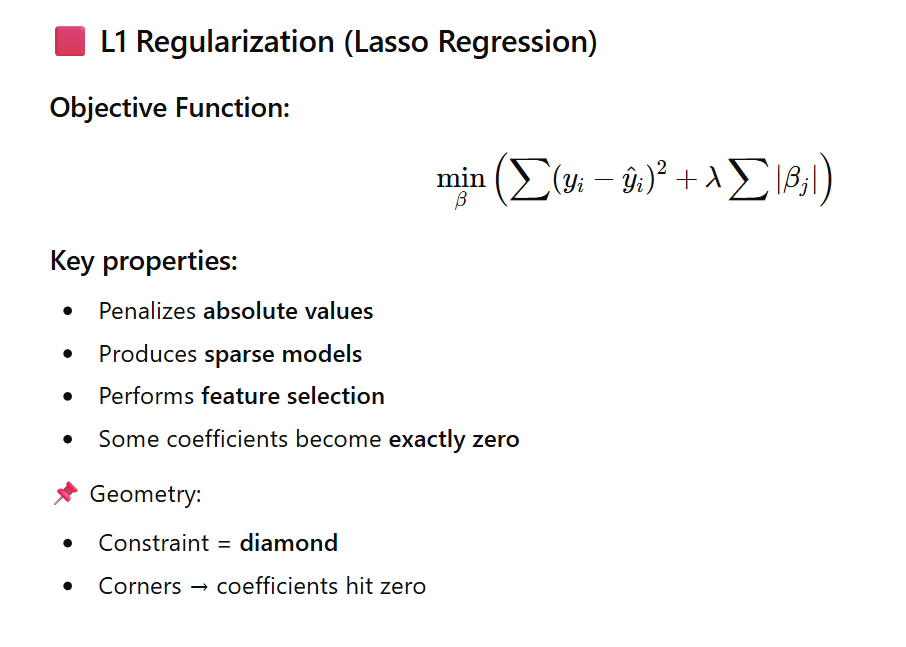
- Penalty = sum of **absolute values** of coefficients:  
  `λ ∑ |w_i|`
- Can shrink some coefficients to **zero** → performs **feature selection** automatically.

### 2. L2 Regularization (Ridge)

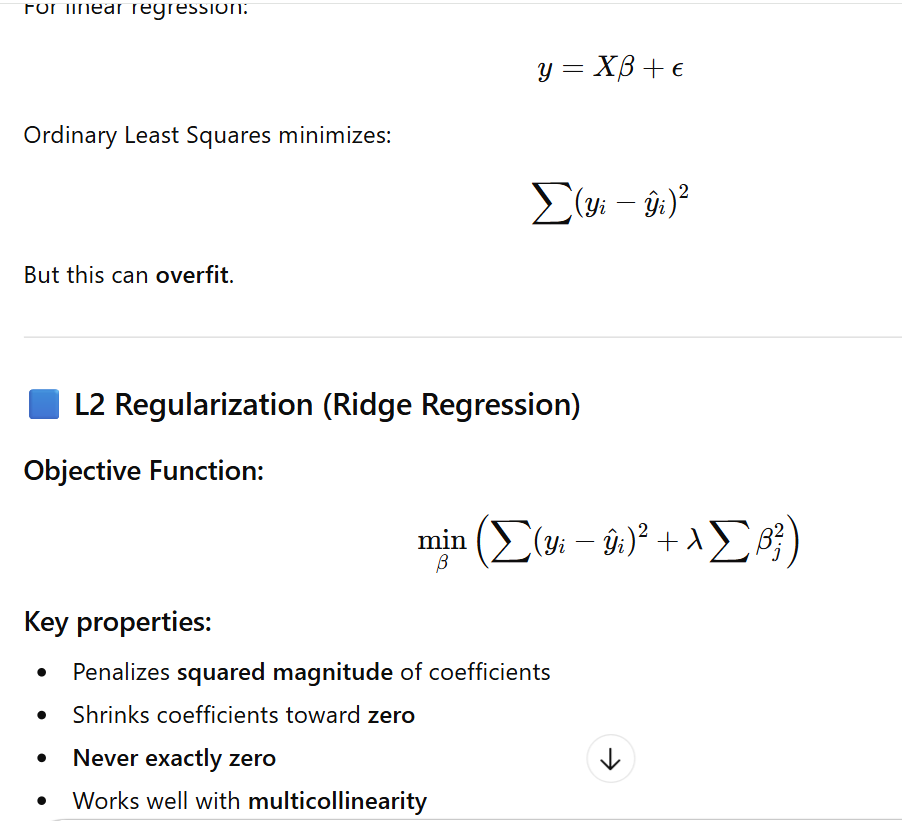
- Penalty = sum of **squared values** of coefficients:  
  `λ ∑ w_i²`
- Shrinks coefficients towards zero but **doesn’t eliminate them**.
- Helps reduce variance and makes the model **more stable**.

### 3. Elastic Net
- Combination of **L1 + L2 penalties**.
- Balances **feature selection** and **stability**.


## 🔹 What is solver in Logistic Regression?

The `solver` parameter specifies the algorithm used to **optimize the model’s weights**  
(i.e., how the model finds the best coefficients to fit the data).

Different solvers are better suited for different **datasets and penalty types**.

---

## 🔹 Common Solvers


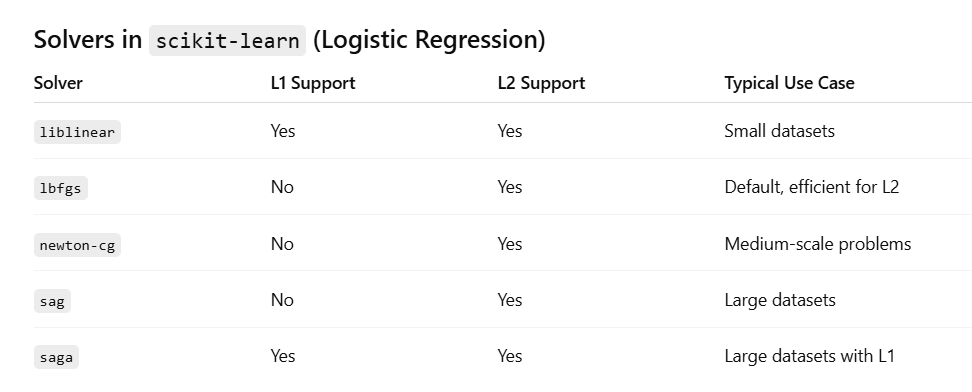

### lbfgs
- Stands for **Limited-memory Broyden–Fletcher–Goldfarb–Shanno algorithm**.  
- Fast, robust, and works well for **large datasets**.  
- Supports only **L2 regularization**.

### liblinear
- Uses **coordinate descent optimization**.  
- Works well for **small datasets**.  
- Supports **both L1 and L2 regularization**.


# 🔑 Important Hyperparameters:

- **C (Inverse of Regularization Strength)**  
  - Smaller `C` → stronger regularization (simpler model, avoids overfitting).  
  - Larger `C` → weaker regularization (more complex model, can overfit).  

- **Penalty**  
  - `"l2"` (Ridge) is default, helps prevent overfitting.  

- **Solver (Algorithm to optimize weights)**  
  - `lbfgs`: fast, works for L2 penalty, good for large datasets.  
  - `liblinear`: works well for small datasets, supports L1 & L2.  


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"],
    "penalty": ["l2","elastic","l1"]
}

grid = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

best_log_reg = grid.best_estimator_

# Train & Test Accuracy after tuning
train_acc_tuned_logreg = accuracy_score(y_train, best_log_reg.predict(X_train))
test_acc_tuned_logreg = accuracy_score(y_test, best_log_reg.predict(X_test))

print("\nLogistic Regression (Tuned)")
print("Best Params:", grid.best_params_)
print("Train Accuracy:", train_acc_tuned_logreg)
print("Test Accuracy:", test_acc_tuned_logreg)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
27 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/


Logistic Regression (Tuned)
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Train Accuracy: 0.9736263736263736
Test Accuracy: 0.9649122807017544


In [ ]:
#knn
# Default KNN
from sklearn.neighbors import KNeighborsClassifier

knn_default = KNeighborsClassifier()
knn_default.fit(X_train, y_train)

train_acc_knn = accuracy_score(y_train, knn_default.predict(X_train))
test_acc_knn = accuracy_score(y_test, knn_default.predict(X_test))

print("KNN (Default)")
print("Train Accuracy:", train_acc_knn)
print("Test Accuracy:", test_acc_knn)


KNN (Default)
Train Accuracy: 0.9472527472527472
Test Accuracy: 0.9122807017543859


## 🔹 Key KNN Hyperparameters

### 1. n_neighbors
- Number of nearest neighbors the model looks at when predicting a class.  
- Examples: `[3, 5, 7, 9, 11, 20]`  
- **Intuition:**  
  - Smaller `n_neighbors` → more sensitive to noise, may overfit.  
  - Larger `n_neighbors` → smoother decision boundary, may underfit.

### 2. weights
- Determines how each neighbor influences the prediction.  
  - `"uniform"` → all neighbors have equal weight.  
  - `"distance"` → closer neighbors have more influence than farther ones.

### 3. metric
- How distance between points is measured.  
- Examples:  
  - `"euclidean"` → straight-line distance (most common).  
  - `"manhattan"` → sum of absolute differences (grid-like distance).


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11,20],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=9, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

best_knn = grid.best_estimator_

train_acc_tuned_knn = accuracy_score(y_train, best_knn.predict(X_train))
test_acc_tuned_knn = accuracy_score(y_test, best_knn.predict(X_test))

print("\nKNN (Tuned)")
print("Best Params:", grid.best_params_)
print("Train Accuracy:", train_acc_tuned_knn)
print("Test Accuracy:", test_acc_tuned_knn)



KNN (Tuned)
Best Params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Train Accuracy: 0.9516483516483516
Test Accuracy: 0.9473684210526315


In [ ]:
#svc
from sklearn.svm import SVC

# Default SVC (kernel='rbf', C=1.0, gamma='scale')
svc = SVC()
svc.fit(X_train, y_train)

# Train & Test accuracy
train_acc_svc = svc.score(X_train, y_train)
test_acc_svc= svc.score(X_test, y_test)

print("SVC (Default)")
print("Train Accuracy:", train_acc_svc)
print("Test Accuracy:", test_acc_svc)

SVC (Default)
Train Accuracy: 0.9186813186813186
Test Accuracy: 0.9298245614035088


## 🔹 Key SVM Hyperparameters

### 1. C
- Regularization parameter: controls the trade-off between **margin width** and **misclassification**.  
- Smaller `C` → wider margin, more tolerance for misclassified points (simpler model, may underfit).  
- Larger `C` → narrower margin, tries to classify all points correctly (complex model, may overfit).  
- Example: `[0.1, 1, 10]`

### 2. kernel
- Function to transform data into higher-dimensional space to make it **linearly separable**.  
- Options:  
  - `"linear"` → no transformation, works well if data is already linear.  
  - `"rbf"` → radial basis function, most common for nonlinear data.  
  - `"poly"` → polynomial kernel, good for polynomial decision boundaries.  
  - `"sigmoid"` → uses sigmoid function, less commonly used.

### 3. gamma
- Defines **influence of a single training example**.  
- Options:  
  - `"scale"` → `1 / (n_features * X.var())` (default, usually good)  
  - `"auto"` → `1 / n_features` (less commonly used)


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define parameter grid
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale"]
}

# Grid Search with CV=10
grid = GridSearchCV(SVC(), param_grid, cv=10, scoring="accuracy")
grid.fit(X_train, y_train)

best_svc = grid.best_estimator_

# Train & Test accuracy
train_acc_tuned_svc = best_svc.score(X_train, y_train)
test_acc_tuned_svc = best_svc.score(X_test, y_test)

print("\nSVC (Tuned)")
print("Best Params:", grid.best_params_)
print("Train Accuracy:", train_acc_tuned_svc)
print("Test Accuracy:", test_acc_tuned_svc)


SVC (Tuned)
Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Train Accuracy: 0.9714285714285714
Test Accuracy: 0.9649122807017544


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Default Decision Tree
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

# Train & Test accuracy
train_acc_dt = dt_default.score(X_train, y_train)
test_acc_dt = dt_default.score(X_test, y_test)

print("Decision Tree (Default)")
print("Train Accuracy:", train_acc_dt)
print("Test Accuracy:", test_acc_dt)

Decision Tree (Default)
Train Accuracy: 1.0
Test Accuracy: 0.9122807017543859


## 🔹 Key Decision Tree Hyperparameters

### 1. max_depth
- Maximum depth of the tree.  
- Controls how deep the tree can grow.  
- Smaller values → simpler tree, may underfit.  
- Larger values → more complex tree, may overfit.  
- Example: `[None, 3, 5, 7, 10]` (`None` → expand until all leaves are pure or contain `min_samples_split` samples)

### 2. min_samples_split
- Minimum number of samples required to split an internal node.  
- Higher value → fewer splits, simpler tree, reduces overfitting.  
- Lower value → more splits, complex tree, may overfit.  
- Example: `[2, 5, 10]`

### 3. criterion
- Function to measure quality of a split.  
- Options:  
  - `"gini"` → Gini impurity (default)  
  - `"entropy"` → Information gain


In [ ]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid
param_grid = {
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

# Grid Search with CV=10
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=10, scoring="accuracy")
grid.fit(X_train, y_train)

best_dt = grid.best_estimator_

# Train & Test accuracy
train_acc_tuned_dt = best_dt.score(X_train, y_train)
test_acc_tuned_dt = best_dt.score(X_test, y_test)

print("\nDecision Tree (Tuned)")
print("Best Params:", grid.best_params_)
print("Train Accuracy:", train_acc_tuned_dt)
print("Test Accuracy:", test_acc_tuned_dt)


Decision Tree (Tuned)
Best Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
Train Accuracy: 0.9912087912087912
Test Accuracy: 0.9298245614035088


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Default Random Forest
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)

[ ]

# Train & Test accuracy
train_acc_rf = rf_default.score(X_train, y_train)
test_acc_rf = rf_default.score(X_test, y_test)

print("Random Forest (Default)")
print("Train Accuracy:", train_acc_rf)
print("Test Accuracy:", test_acc_rf)

Random Forest (Default)
Train Accuracy: 1.0
Test Accuracy: 0.956140350877193


## 🔹 Key Random Forest Hyperparameters

### 1. n_estimators
- Number of trees in the forest.  
- More trees → more stable predictions, usually better performance, but slower training.  
- Example: `[50, 100, 200]`

### 2. max_depth
- Maximum depth of each tree in the forest.  
- Controls complexity of individual trees.  
- Smaller → simpler trees, may underfit; larger → deeper trees, may overfit.  
- Example: `[None, 5, 10, 15]`

### 3. min_samples_split
- Minimum number of samples required to split a node.  
- Higher → fewer splits, simpler trees; lower → more splits, complex trees.  
- Example: `[2, 5, 10]`

### 4. criterion
- Function to measure the quality of a split.  
- Options:  
  - `"gini"` → Gini impurity  
  - `"entropy"` → Information gain


In [ ]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini"]
}

# Grid Search with CV=10
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=10, scoring="accuracy")
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

# Train & Test accuracy
train_acc_tuned_rf= best_rf.score(X_train, y_train)
test_acc_tuned_rf= best_rf.score(X_test, y_test)

print("\nRandom Forest (Tuned)")
print("Best Params:", grid.best_params_)
print("Train Accuracy:", train_acc_tuned_rf)
print("Test Accuracy:", test_acc_tuned_rf)


Random Forest (Tuned)
Best Params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Train Accuracy: 1.0
Test Accuracy: 0.956140350877193


In [ ]:
# Default XGBoost
from xgboost import XGBClassifier
xgb_default = XGBClassifier()
xgb_default.fit(X_train, y_train)

# Train & Test Accuracy
train_acc_xgb = accuracy_score(y_train, xgb_default.predict(X_train))
test_acc_xgb = accuracy_score(y_test, xgb_default.predict(X_test))

print("XGBoost (Default)")
print("Train Accuracy:", train_acc_xgb)
print("Test Accuracy:", test_acc_xgb)

XGBoost (Default)
Train Accuracy: 1.0
Test Accuracy: 0.956140350877193


## 🔹 Key Hyperparameters in XGBoost

### 1. n_estimators
- Number of boosting rounds (trees).  
- Too high → risk of overfitting.  
- Too low → underfitting.

### 2. max_depth
- Controls model complexity.  
- Higher → more complex trees, may overfit.  
- Lower → simpler trees, may underfit.

### 3. learning_rate (eta)
- Step size shrinkage for each boosting step.  
- Small values → slower learning, usually better generalization.

### 4. subsample
- Fraction of training samples used per tree.  
- Helps reduce overfitting by introducing randomness.

### 5. colsample_bytree
- Fraction of features used per tree.  
- Adds randomness, reduces overfitting.

### 6. gamma
- Minimum loss reduction required to make a split.  
- Higher → more conservative tree, fewer splits.

### 7. reg_alpha and reg_lambda
- L1 (`reg_alpha`) and L2 (`reg_lambda`) regularization on weights.  
- Helps control overfitting.


In [ ]:
# Parameter Grid
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

# Grid Search with CV=10
grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid, cv=10, scoring='accuracy', n_jobs=-1
)
grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_

# Train & Test Accuracy
train_acc_tuned_xgb= accuracy_score(y_train, best_xgb.predict(X_train))
test_acc_tuned_xgb= accuracy_score(y_test, best_xgb.predict(X_test))

print("\nXGBoost (Tuned)")
print("Best Params:", grid.best_params_)
print("Train Accuracy:", train_acc_tuned_xgb)
print("Test Accuracy:", test_acc_tuned_xgb)


XGBoost (Tuned)
Best Params: {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 50, 'subsample': 0.7}
Train Accuracy: 1.0
Test Accuracy: 0.956140350877193


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:54:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
# Default AdaBoost
adb_default = AdaBoostClassifier(random_state=42)
adb_default.fit(X_train, y_train)

# Train & Test Accuracy
train_acc_adb = accuracy_score(y_train, adb_default.predict(X_train))
test_acc_adb= accuracy_score(y_test, adb_default.predict(X_test))

print("AdaBoost (Default)")
print("Train Accuracy:", train_acc_adb)
print("Test Accuracy:", test_acc_adb)

AdaBoost (Default)
Train Accuracy: 1.0
Test Accuracy: 0.956140350877193


## 🔹 Key AdaBoost Hyperparameters

### 1. n_estimators
- Number of boosting rounds (weak learners).  
- More estimators → more complex ensemble → better learning but risk of overfitting.  
- Example: `[50, 100, 150]`

### 2. learning_rate
- Weight applied to each weak learner.  
- Smaller values → slower learning, better generalization.  
- Larger values → faster learning, may overfit.  
- Example: `[0.01, 0.1, 0.5, 1]`

### 3. algorithm
- Type of boosting algorithm.  
- `"SAMME"` → original AdaBoost algorithm (multi-class support).  
- `"SAMME.R"` → uses probabilities for more accurate learning (usually faster convergence).


In [ ]:
# Parameter Grid
param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.5, 1],
    "algorithm": ["SAMME", "SAMME.R"]
}

# Grid Search with CV=10
grid = GridSearchCV(AdaBoostClassifier(random_state=42), param_grid, cv=10, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

best_adb = grid.best_estimator_

# Train & Test Accuracy
train_acc_tuned_adb= accuracy_score(y_train, best_adb.predict(X_train))
test_acc_tuned_adb= accuracy_score(y_test, best_adb.predict(X_test))

print("\nAdaBoost (Tuned)")
print("Best Params:", grid.best_params_)
print("Train Accuracy:", train_acc_tuned_adb)
print("Test Accuracy:", test_acc_tuned_adb)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
120 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/util


AdaBoost (Tuned)
Best Params: {'algorithm': 'SAMME', 'learning_rate': 0.5, 'n_estimators': 150}
Train Accuracy: 1.0
Test Accuracy: 0.9649122807017544


In [ ]:
import pandas as pd

# Collect the results for all models
results = {
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVC",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "AdaBoost"
    ],
    "Train Accuracy (Default)": [
        train_acc_logreg,  # Replace with your variable
        train_acc_knn,
        train_acc_svc,
        train_acc_dt,
        train_acc_rf,
        train_acc_xgb,
        train_acc_adb
    ],
    "Test Accuracy (Default)": [
        test_acc_logreg,
        test_acc_knn,
        test_acc_svc,
        test_acc_dt,
        test_acc_rf,
        test_acc_xgb,
        test_acc_adb
    ],
    "Train Accuracy (Tuned)": [
        train_acc_tuned_logreg,
        train_acc_tuned_knn,
        train_acc_tuned_svc,
        train_acc_tuned_dt,
        train_acc_tuned_rf,
        train_acc_tuned_xgb,
        train_acc_tuned_adb
    ],
    "Test Accuracy (Tuned)": [
        test_acc_tuned_logreg,
        test_acc_tuned_knn,
        test_acc_tuned_svc,
        test_acc_tuned_dt,
        test_acc_tuned_rf,
        test_acc_tuned_xgb,
        test_acc_tuned_adb
    ]
}

# Create DataFrame
df_results = pd.DataFrame(results)

# Display table
df_results


,Model,Train Accuracy (Default),Test Accuracy (Default),Train Accuracy (Tuned),Test Accuracy (Tuned)
0,Logistic Regression,0.947253,0.956140,0.973626,0.964912
1,KNN,0.947253,0.912281,0.951648,0.947368
2,SVC,0.918681,0.929825,0.971429,0.964912
3,Decision Tree,1.000000,0.912281,0.991209,0.929825
4,Random Forest,1.000000,0.956140,1.000000,0.956140
5,XGBoost,1.000000,0.956140,1.000000,0.956140
6,AdaBoost,1.000000,0.956140,1.000000,0.964912
